# Configuración previa de simulación

In [ ]:
# Importacion de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from enum import Enum


## Parámetros del problema

In [ ]:
# Flow properties and characteristics
Re = np.array([100,400]) # Reynolds
L = 1 # m Cavity side lenght
# Assuming that the fluid is air and it is incompressible
rho = 1.225 # kg/m3 density
mu = 1.81E-5 # Pa-s dynamic viscosity
nu = mu/rho # m2/s kinematic viscosity

U_wall = mu*Re/(rho*L) # Velocity of moving wall

for Re_value in range(len(Re)):
  print(f"The wall velocity for Re:{Re[Re_value]} is U = {U_wall[Re_value]:.5f} m/s")


The wall velocity for Re:100 is U = 0.00148 m/s
The wall velocity for Re:400 is U = 0.00591 m/s


In [ ]:
# Geomtry generation
# constant Delta x and Delta y and Deltax = Deltay is proposed
# The number of cells will be based on the number of divisions
# N numero de divisiones
def generate_geometry(N):
  dx = L/N # change in x direction
  dy = dx # change in y direction
  ###############################################################################
  # Vertices generation

  x,y = np.meshgrid(np.linspace(0,L,N+1),np.linspace(0,L,N+1))

  vertices_points = np.array([x.flatten(),y.flatten()]).T


  cells_number = N**2 # Number of cells

  # List that stores the cells gropued by vertices
  Cells_vertices = np.zeros((cells_number,4),dtype=int)

  def idx(i, j, ncols):
    # Function that gives an index number acccording to a i,j coordinate
      return i * (ncols + 1) + j

  c = 0

  for i in range(N):
      for j in range(N):
          v0 = idx(i, j, N)
          v1 = idx(i, j+1, N)
          v2 = idx(i+1, j+1, N)
          v3 = idx(i+1, j, N)

          Cells_vertices[c] = [v0, v1, v2, v3]
          c += 1
  ###############################################################################

  # Centroids definition

  centroids = np.zeros((cells_number,2)) # Array that will store the centroid coordinates

  for c in range(cells_number):
      # With the cells vertices index, we obtain the alues of their coordinates in vertices points
      # TH ecentroid is the mean point
      centroids[c] = vertices_points[Cells_vertices[c]].mean(axis=0)
  return cells_number, vertices_points, centroids, Cells_vertices, dx

In [ ]:
# Clases creation

# Class for nodes
#==============================================================================

class Node:
    def __init__(self, x, y, id):
        # How to access node[i] coordinates-> x = node[i].x; y = node[i].y; id = node[i].id
        self.x = x
        self.y = y
        self.id = id

# Class for BC
#=============================================================================

class BoundaryType(Enum):
  INTERIOR = 0
  WALL = 1
  MOVING_WALL = 2

#class for faces/edges
#==============================================================================

class Face:
    def __init__(self, n1, n2):

        self.nodes = [n1, n2] # NOdes to define edge

        self.cell_L = None # Cell at the left of the edge
        self.cell_R = None # Cel at the right of the edge

        self.midpoint = None # edge midpoint
        self.normal = None # nomar vector of the edge

        self.boundary = BoundaryType.INTERIOR # if edge has BC

# class for cells
#==============================================================================

class Cell:
    def __init__(self, nodes):

        self.nodes = nodes
        self.faces = []
        self.area = None
        self.centroid = None
        self.w = None # Vorticity
        self.phi = None # Stream function
        self.u = 0.0 # Velocity in x direction
        self.v = 0.0 # Velocity in y direction
        self.W = None # West Cell
        self.E = None # East Cell
        self.S = None # South Cell
        self.N = None # North Cell
        self.neighbours = None
        self.tetha = None
#==============================================================================

In [ ]:
# Function to find normal vectors
def unit_normal(dx,dy):
    n = np.array([-dy,dx])

    return n/np.linalg.norm(n)

In [ ]:
def meshing(N):
  cells_number, vertices_points, centroids, Cells_vertices, dx = generate_geometry(N)
  #####################################################
  nodes = [] # Here are stored the nodes as object defined by x,y coordinates


  for i,p in enumerate(vertices_points):

      nodes.append(Node(p[0], p[1], i))
  #####################################################

  # Cells object creation
  cells = []

  for idx in Cells_vertices:
      cell_nodes = [nodes[i] for i in idx]
      cells.append(Cell(cell_nodes))

  # Center of cells
  for i, c in enumerate(cells):
      x = [n.x for n in c.nodes]
      y = [n.y for n in c.nodes]

      c.area = dx**2
      c.centroid = centroids[i]
  #####################################################

  faces_dict = {}
  faces = []
  # Now we make sure that we have no edges repeated/duplicated (e.g [1,4] and [4,1] -> same edge)
  for c_id, cell in enumerate(cells):
      # Obtenemos los nodos de la celda actual
      node_objects = cell.nodes
      n = len(node_objects)

      # Generamos las caras/edges de ESTA celda (ASUMIMOS ORDEN ANTIHORARIO)
      for i in range(n):
          n1 = node_objects[i]
          n2 = node_objects[(i + 1) % n] # El siguiente nodo (cierra el triángulo/polígono)

          # Creamos una llave única ordenada para el diccionario
          # First we sort the values stored previously to identyfy repeated edges -> [4,1] now is [1,4]
          edge_key = tuple(sorted((n1.id, n2.id))) # we made it a tuple so it can not be modified

          if edge_key not in faces_dict:

              new_face = Face(n1, n2)

              new_face.cell_L = c_id

              faces_dict[edge_key] = new_face
              faces.append(new_face)
              cell.faces.append(new_face) # Guardar referencia en la celda
          else:
              # La cara ya existe, esta celda es la "Derecha"
              existing_face = faces_dict[edge_key]
              existing_face.cell_R = c_id
              cell.faces.append(existing_face)

  #####################################################################

  # Midpoint and normal vectors calc in each face
  for f in faces:
      # Extraction of edge points
      p1 = f.nodes[0]
      p2 = f.nodes[1]
      # calc of midpoint
      f.midpoint = [
          (p1.x + p2.x)/2,
          (p1.y + p2.y)/2
      ]
      dx_i = p2.x - p1.x
      dy_i = p2.y - p1.y

      f.normal = unit_normal(dx_i,dy_i)
      # BCs definition
      tol = dx/1e5

      if f.cell_R is None:
          if abs(f.midpoint[1] - 1.0) < tol:
              f.boundary = BoundaryType.MOVING_WALL
          else:
              f.boundary = BoundaryType.WALL
      else:
          f.boundary = BoundaryType.INTERIOR
  #####################################################################

  for c_id, c in enumerate(cells):
      c.neighbours = []

      for f in c.faces:

          if f.boundary == BoundaryType.INTERIOR:
              continue

          # Identificar la celda vecina correctamente
          if f.cell_L == c_id:
              neighbor = f.cell_R
              normal = f.normal
          else:
              neighbor = f.cell_L
              normal = -np.array(f.normal)  # IMPORTANTE: cambiar orientación

          nx, ny = normal

          if abs(nx) > abs(ny):
              if nx > 0:
                  c.E = neighbor
              else:
                  c.W = neighbor
          else:
              if ny > 0:
                  c.N = neighbor
              else:
                  c.S = neighbor
          # S,W,N,E
          c.neighbours.append(neighbor)
  return nodes, cells, faces, dx

In [ ]:
N = [20,40,80]

nodes20, cells20, faces20, dx20 = meshing(N[0])
nodes40, cells40, faces40, dx40 = meshing(N[1])
nodes80, cells80, faces80, dx80 = meshing(N[2])
nodes400, cells400, faces400, dx400 = meshing(N[1])

# Planteamiento de Solver

In [ ]:
def solve_streamfunction_FVM(cells, dx):

    for c_id, c in enumerate(cells):

        a_sum = 0
        psi_sum = 0

        for f in c.faces:

            A_f = dx        # longitud de la cara
            d = dx          # distancia entre centroides

            if f.boundary == BoundaryType.INTERIOR:

                # identificar vecino
                if f.cell_L == c_id:
                    nb = cells[f.cell_R]
                else:
                    nb = cells[f.cell_L]

                a = A_f / d   # 1

                psi_sum += a * nb.phi
                a_sum += a

            else:
                # frontera → Dirichlet ψ = 0
                psi_B = 0.0
                d = dx / 2.0
                a = A_f / d

                psi_sum += a * psi_B
                a_sum += a

        c.phi = (psi_sum + c.w * c.area) / a_sum

In [ ]:

def vorticity_top_wall(cells, dx, U_wall, N):

    for i in range(N):

        j = N - 1  # fila superior
        c = cells[j*N + i]

        c1 = cells[(j-1)*N + i]
        c2 = cells[(j-2)*N + i]

        phi_j_1 = (6*dx*U_wall - 3*c.w + 6*c1.phi - c2.phi)/2
        c.w = -(phi_j_1 -2*c.phi + c1.phi)/dx**2



In [ ]:
def apply_vorticity_bc(cells, N, dx, U_lid):

    psi_wall = 0.0

    for j in range(N):
        for i in range(N):

            c = cells[j*N + i]

            # BOTTOM WALL
            if j == 0:
                c.w = -2 * (c.phi - psi_wall) / dx**2

            # mOVING wall
            #elif j == N-1:

            #    c.w = (
            #        -2 * (c.phi - psi_wall) / dx**2
            #        - 2 * U_lid / dx
            #    )

            # Left wall
            elif i == 0:
                c.w = -2 * (c.phi - psi_wall) / dx**2
            # Right wall
            elif i == N-1:
                c.w = -2 * (c.phi - psi_wall) / dx**2

In [ ]:
def update_vorticity(cells, N, dx, dt, nu):

    new_w = [0.0] * len(cells)

    for j in range(1, N-1):
        for i in range(1, N-1):

            c = cells[j*N + i]

            cN = cells[(j+1)*N + i]
            cS = cells[(j-1)*N + i]
            cE = cells[j*N + (i+1)]
            cW = cells[j*N + (i-1)]

            # Derivadas (centrales)# Upwind en x
            if c.u > 0:
                dwdx = (c.w - cW.w) / dx
            else:
                dwdx = (cE.w - c.w) / dx

            # Upwind en y
            if c.v > 0:
                dwdy = (c.w - cS.w) / dx
            else:
                dwdy = (cN.w - c.w) / dx

            laplace_w = (
                cE.w + cW.w + cN.w + cS.w - 4*c.w
            ) / dx**2

            # Transporte
            convection = c.u * dwdx + c.v * dwdy
            diffusion = nu * laplace_w

            new_w[j*N + i] = c.w + dt * (-convection + diffusion)

    # actualizar
    for idx in range(len(cells)):
        cells[idx].w = new_w[idx]

In [ ]:

def update_temperature(cells, N, dx, dt, alpha, Tc, Th):

    new_theta = [0.0] * len(cells)

    for j in range(1, N-1):
        for i in range(1, N-1):

            c = cells[j*N + i]

            cN = cells[(j+1)*N + i]
            cS = cells[(j-1)*N + i]
            cE = cells[j*N + (i+1)]
            cW = cells[j*N + (i-1)]



            # Derivadas (centrales)# Upwind en x
            if c.u > 0:
                dTdx = (c.theta - cW.theta) / dx

            else:
                dTdx = (cE.theta - c.theta) / dx

            # Upwind en y
            if c.v > 0:
                dTdy = (c.theta - cS.theta) / dx

            else:
                dTdy = (cN.theta - c.theta) / dx

            laplace_theta = (
                cE.theta + cW.theta + cN.theta + cS.theta - 4*c.theta
            ) / dx**2

            # Transporte
            convection = c.u * dTdx + c.v * dTdy
            diffusion = alpha * laplace_theta

            new_theta[j*N + i] = c.theta + dt * (-convection + diffusion)

    # actualizar
    for idx in range(len(cells)):
        cells[idx].theta = new_theta[idx]


In [ ]:
"""
def update_temperature(cells, N, dx, dt, alpha):

    new_theta = [c.theta for c in cells]  # copiar valores

    for j in range(1, N-1):
        for i in range(1, N-1):

            c = cells[j*N + i]

            cN = cells[(j+1)*N + i]
            cS = cells[(j-1)*N + i]
            cE = cells[j*N + (i+1)]
            cW = cells[j*N + (i-1)]

            # Upwind en x
            if c.u > 0:
                dTdx = (c.theta - cW.theta) / dx
            else:
                dTdx = (cE.theta - c.theta) / dx

            # Upwind en y
            if c.v > 0:
                dTdy = (c.theta - cS.theta) / dx
            else:
                dTdy = (cN.theta - c.theta) / dx

            laplace_theta = (
                cE.theta + cW.theta + cN.theta + cS.theta - 4*c.theta
            ) / dx**2

            convection = c.u * dTdx + c.v * dTdy
            diffusion = alpha * laplace_theta

            new_theta[j*N + i] = c.theta + dt * (-convection + diffusion)

    # actualizar
    for idx in range(len(cells)):
        cells[idx].theta = new_theta[idx]
  """

'\ndef update_temperature(cells, N, dx, dt, alpha):\n\n    new_theta = [c.theta for c in cells]  # copiar valores\n\n    for j in range(1, N-1):\n        for i in range(1, N-1):\n\n            c = cells[j*N + i]\n\n            cN = cells[(j+1)*N + i]\n            cS = cells[(j-1)*N + i]\n            cE = cells[j*N + (i+1)]\n            cW = cells[j*N + (i-1)]\n\n            # Upwind en x\n            if c.u > 0:\n                dTdx = (c.theta - cW.theta) / dx\n            else:\n                dTdx = (cE.theta - c.theta) / dx\n\n            # Upwind en y\n            if c.v > 0:\n                dTdy = (c.theta - cS.theta) / dx\n            else:\n                dTdy = (cN.theta - c.theta) / dx\n\n            laplace_theta = (\n                cE.theta + cW.theta + cN.theta + cS.theta - 4*c.theta\n            ) / dx**2\n\n            convection = c.u * dTdx + c.v * dTdy\n            diffusion = alpha * laplace_theta\n\n            new_theta[j*N + i] = c.theta + dt * (-convection + 

In [ ]:
def apply_temperature_bc(cells, N, Th, Tc):
    for j in range(N):
        for i in range(N):
            c = cells[j*N + i]

            # SUELO (Hot wall)
            if j == 0:
                c.theta = 0

            # TECHO (Cold wall)
            elif j == N-1:
                c.theta = 1.0

            # PAREDES LATERALES (Adiabáticas: dT/dx = 0)
            elif i == 0:
                # Copia el valor de la celda a la derecha
                c.theta = cells[j*N + (i+1)].theta
            elif i == N-1:
                # Copia el valor de la celda a la izquierda
                c.theta = cells[j*N + (i-1)].theta

In [ ]:
def dt_calc(Co, cells, dx, alpha):
  Co = 0.2
  u_max = max(abs(c.u) for c in cells)
  v_max = max(abs(c.v) for c in cells)

  dt_conv = Co * dx / (u_max + v_max + 1e-8)
  dt_diff1 = dx**2 / (4 * nu)
  dt_diff2 = dx**2 / (4 * alpha)
  dt = min(dt_conv, dt_diff1, dt_diff2)
  return dt

In [ ]:
def update_velocity(cells, N, dx):

    for j in range(1, N-1):
        for i in range(1, N-1):

            c = cells[j*N + i]

            cN = cells[(j+1)*N + i]
            cS = cells[(j-1)*N + i]
            cE = cells[j*N + (i+1)]
            cW = cells[j*N + (i-1)]

            c.u = (cN.phi - cS.phi) / (2*dx)
            c.v = -(cE.phi - cW.phi) / (2*dx)

In [ ]:
def nusselt_prom(T, dx):
    """
    Calcula el Nu promedio en la pared inferior (j=0)
    T: Matriz de temperatura (N x N)
    dx: Tamaño de la celda (float)
    """
    N = T.shape[0]
    nu_local = np.zeros(N)

    # 1. Calcular el Nusselt local en cada punto 'i' de la pared
    # Usamos una aproximación de segundo orden hacia adelante (Forward 2nd Order)
    # para mayor precisión en el gradiente de la pared.
    for i in range(N):
        # T[j, i] -> j es fila (y), i es columna (x)
        t0 = T[0, i] # Pared (Temp conocida o fija)
        t1 = T[1, i] # Primer nodo interno
        t2 = T[2, i] # Segundo nodo interno

        # Fórmula de diferencias finitas de segundo orden para la derivada:
        nu_local[i] = abs((-3*t0 + 4*t1 - t2) / (2*dx))

    # 2. Calcular el promedio usando la regla del trapecio
    # (Es más exacto que un promedio simple si dx no es uniforme,
    # aunque aquí dx es constante)
    nu_promedio = np.trapezoid(nu_local, dx=dx) / 1.0

    return nu_promedio, nu_local

# Uso:
# nu_prom, nu_vec = calcular_nusselt_promedio(T_final, dx)
# print(f"El número de Nusselt promedio es: {nu_prom:.4f}")

In [ ]:

def solver(N, U_wall, cells, dx):

  diff = 1.0
  iter_global = 0
  n_iter_max = 500
  Co = 0.2
  tol = 1e-5
  dt0 = 0.01
  Tc = 25+ 273.15 #K
  Th = 350 #K
  k = 0.024 #W/m-k
  cp = 1005 # J/kgK
  rho = 1.225 # kg/m3
  alpha = k/(rho*cp)
  #if isinstance(U_wall, np.ndarray):
  U_wall = U_wall # Using the first value for this simulation run


  # Para guardar la última solución
  u_final = None
  v_final = None
  w_final = None
  phi_final = None
  T_final = None

  u_history = []
  v_history = []
  iter_num = []
  diff_num = []
  # Initialize phi and vorticity for all cells
  for c in cells:
      c.phi = 0.0
      c.w = 0.0
      c.theta = 0

  while diff > tol:

      iter_global += 1

      # Guardar phi anterior
      phi_old = [c.phi for c in cells]

      for n in range(n_iter_max):

          dt = dt0

          solve_streamfunction_FVM(cells, dx)
          update_velocity(cells, N, dx)
          apply_vorticity_bc(cells, N, dx, U_wall)
          vorticity_top_wall(cells, dx, U_wall, N)
          update_vorticity(cells, N, dx, dt, nu)
          apply_temperature_bc(cells, N, Th, Tc)
          update_temperature(cells, N, dx, dt, alpha, Tc, Th)

          dt0 = dt_calc(Co, cells, dx, alpha)

      # Calcular error después de las 500 iteraciones
      diff = max(
      abs(c.phi - phi_old[i]) / (abs(phi_old[i]) + 1e-8)
      for i, c in enumerate(cells)
      )

      print(f"Iter global: {iter_global}, diff: {diff:.2e}")
      iter_num.append(iter_global)
      diff_num.append(diff)

      # Guardar SIEMPRE la última iteración
      u_final = [c.u for c in cells]
      v_final = [c.v for c in cells]
      w_final = [c.w for c in cells]
      phi_final = [c.phi for c in cells]
      T_final = [c.theta for c in cells]

      u_history.append([c.u for c in cells])
      v_history.append([c.v for c in cells])


  return u_final, v_final, w_final, phi_final, T_final, u_history, v_history, iter_num, diff_num

In [ ]:
u_final20, v_final20, w_final20, phi_final20, T_final20, u_history20, v_history20, iter_num20, diff_num20 = solver(N[0], U_wall[0], cells20, dx20)

Iter global: 1, diff: 1.42e+04
Iter global: 2, diff: 4.48e-02
Iter global: 3, diff: 1.14e-03
Iter global: 4, diff: 3.16e-05
Iter global: 5, diff: 8.82e-07


In [ ]:
u_final40, v_final40, w_final40, phi_final40, T_final40, u_history40, v_history40, iter_num40, diff_num40 = solver(N[1], U_wall[0], cells40, dx40)

Iter global: 1, diff: 1.25e+04
Iter global: 2, diff: 8.67e-01
Iter global: 3, diff: 5.92e-01
Iter global: 4, diff: 6.56e-02
Iter global: 5, diff: 1.29e-02
Iter global: 6, diff: 2.49e-03
Iter global: 7, diff: 4.78e-04
Iter global: 8, diff: 9.19e-05
Iter global: 9, diff: 1.77e-05
Iter global: 10, diff: 3.41e-06


In [ ]:
u_final80, v_final80, w_final80, phi_final80, T_final80, u_history80, v_history80, iter_num80, diff_num80 = solver(N[2], U_wall[0], cells80, dx80)

Iter global: 1, diff: 2.52e+04
Iter global: 2, diff: 1.68e+01
Iter global: 3, diff: 1.19e+00
Iter global: 4, diff: 4.33e-01
Iter global: 5, diff: 8.81e-01
Iter global: 6, diff: 3.31e+00
Iter global: 7, diff: 2.72e+01
Iter global: 8, diff: 4.24e+01
Iter global: 9, diff: 2.27e+01
Iter global: 10, diff: 6.08e+00
Iter global: 11, diff: 3.87e+00
Iter global: 12, diff: 5.83e+00
Iter global: 13, diff: 4.35e+00
Iter global: 14, diff: 2.49e+00
Iter global: 15, diff: 1.57e+00
Iter global: 16, diff: 2.19e+00
Iter global: 17, diff: 6.11e+00
Iter global: 18, diff: 3.85e+00
Iter global: 19, diff: 4.18e+00
Iter global: 20, diff: 1.72e+00
Iter global: 21, diff: 1.07e+00
Iter global: 22, diff: 1.12e+00
Iter global: 23, diff: 1.11e+00
Iter global: 24, diff: 1.16e+00
Iter global: 25, diff: 4.90e-01
Iter global: 26, diff: 3.85e-01
Iter global: 27, diff: 5.34e-01
Iter global: 28, diff: 9.74e-01
Iter global: 29, diff: 6.61e-01
Iter global: 30, diff: 3.36e-01
Iter global: 31, diff: 2.11e-01
Iter global: 32, 

In [ ]:
N_map = {1: 20, 2: 40, 3: 80}
resultados = {}

for res in N:
    # 1. Acceder dinámicamente a los datos originales
    # (Asumiendo que están en el namespace global, aunque lo ideal es tenerlos en una lista)
    u_raw = globals()[f'u_final{res}']
    v_raw = globals()[f'v_final{res}']
    phi_raw = globals()[f'phi_final{res}']
    T_raw = globals()[f'T_final{res}']
    dx = globals()[f'dx{res}']
    w = globals()[f'w_final{res}']
    #n_size = N_map[res]

    # 2. Procesar y guardar en el diccionario
    resultados[res] = {
        'u': np.array(u_raw).reshape(res, res),
        'v': np.array(v_raw).reshape(res, res),
        'phi': np.array(phi_raw).reshape(res, res),
        'T': np.array(T_raw).reshape(res, res),
        'w': np.array(w).reshape(res, res)

    }

    # 3. Calcular Nusselt
    nu_prom, nu_loc = nusselt_prom(resultados[res]['T'], dx)
    resultados[res]['nu_prom'] = nu_prom
    resultados[res]['nu_loc'] = nu_loc

    # CALCULO MAGNITUD VELocidad
    resultados[res]['V'] = np.sqrt(resultados[res]['u']**2 + resultados[res]['v']**2)

KeyError: 'u_final80'

In [ ]:
plt.rcParams.update({
    "text.usetex": False, # Explicitly disable LaTeX rendering
    "mathtext.fontset": "stix",
    "font.family": "STIXGeneral",
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "axes.labelsize": 15,
    "axes.titlesize": 15,
})

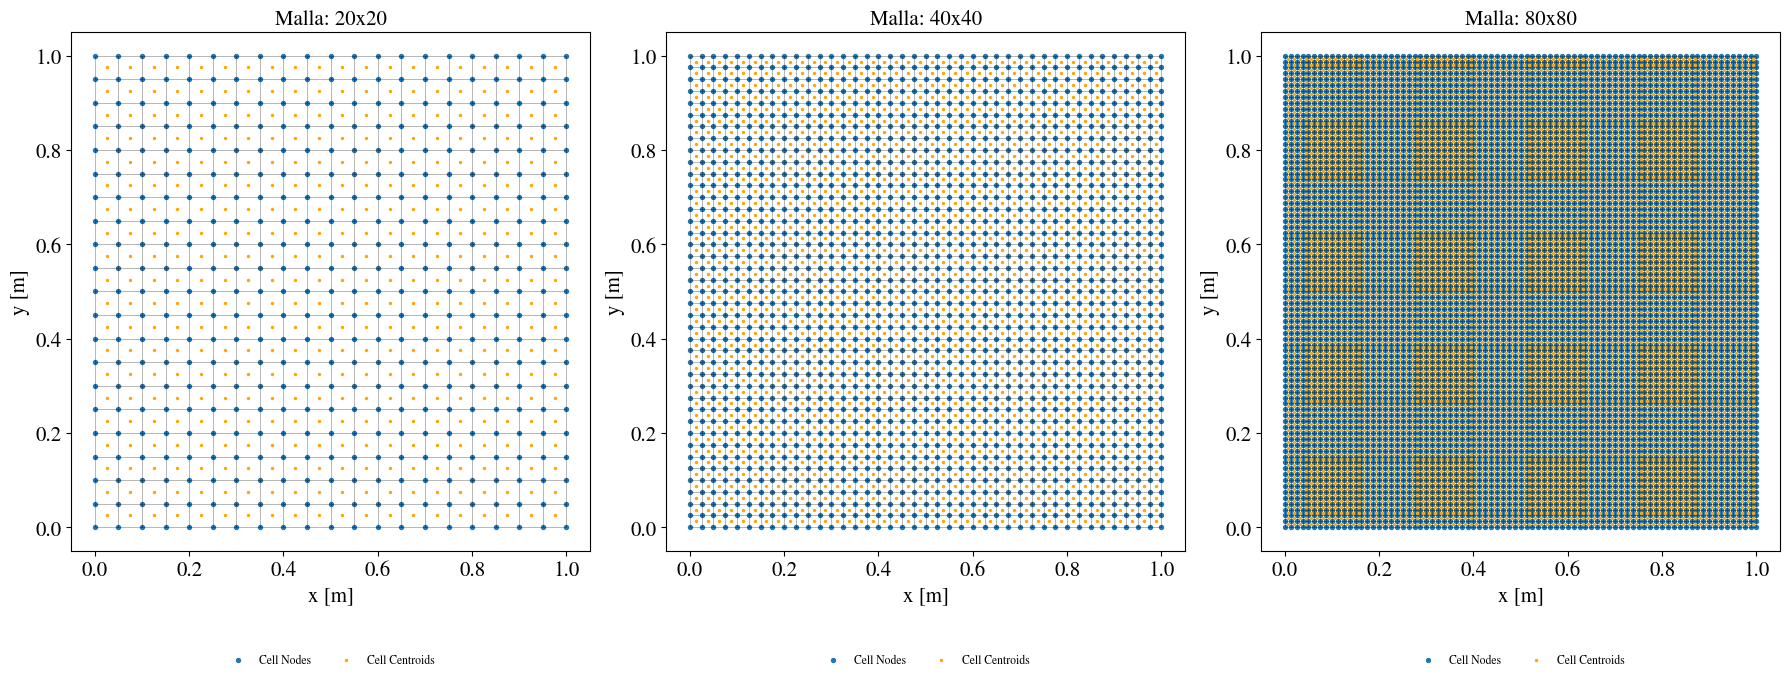

In [ ]:
from matplotlib.collections import LineCollection

# 1. Aumentamos un poco el alto para que el 'equal' no deje tanto aire vertical
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, res in enumerate(N):
    cells_number, vertices_points, centroids, Cells_vertices, dx = generate_geometry(res)
    ax = axes[i]


    ax.scatter(vertices_points[:,0], vertices_points[:,1], s=8, label="Cell Nodes")
    ax.scatter(centroids[:,0], centroids[:,1], s=2, color="orange", label="Cell Centroids")

    x_coords = vertices_points[:,0]
    y_coords = vertices_points[:,1]


    h_lines = [((x_coords.min(), yi), (x_coords.max(), yi)) for yi in np.unique(y_coords)]
    v_lines = [((xi, y_coords.min()), (xi, y_coords.max())) for xi in np.unique(x_coords)]


    lc_h = LineCollection(h_lines, colors='black', linewidths=0.5, alpha=0.4)
    lc_v = LineCollection(v_lines, colors='black', linewidths=0.5, alpha=0.4)

    ax.add_collection(lc_h)
    ax.add_collection(lc_v)


    ax.set_title(f"Malla: {res}x{res}")
    ax.set_ylabel("y [m]")
    ax.set_xlabel("x [m]")


    ax.set_aspect('equal', adjustable='box')

    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.18),
              ncol=2, frameon=False, fontsize='small')

    ax.set_aspect('equal', adjustable='box')
    ax.set_ylabel("y [m]")
    ax.set_xlabel("x [m]")


plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

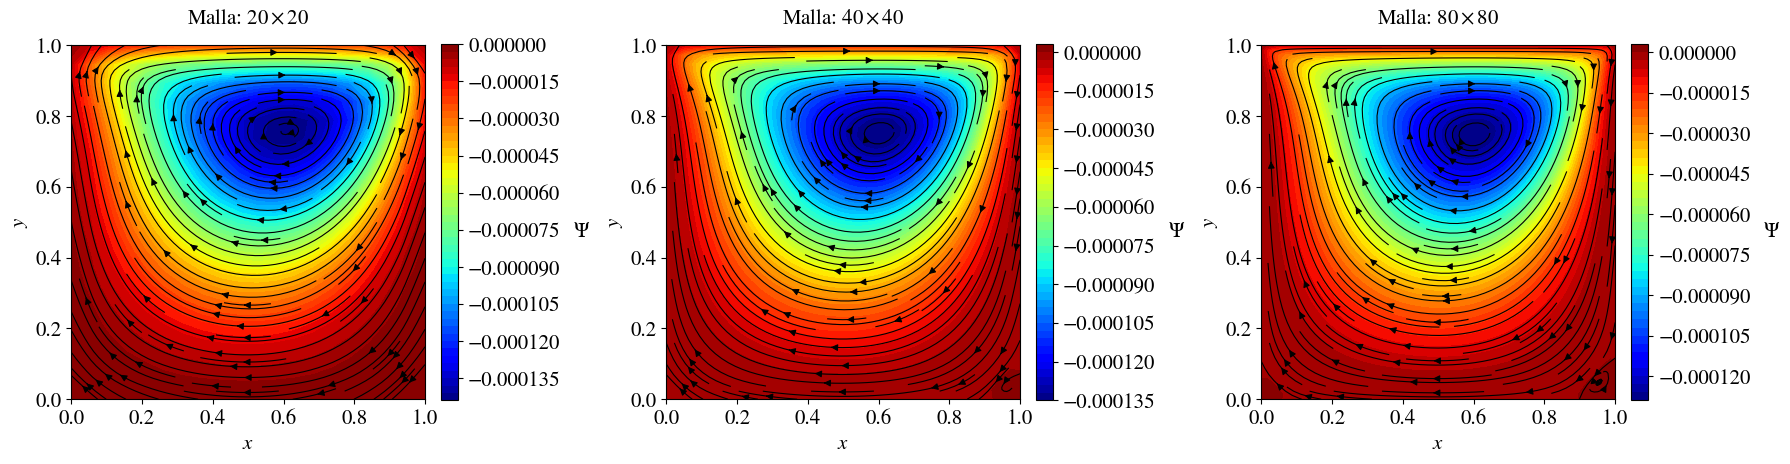

In [ ]:
# Configuramos la figura con un ancho mayor para dar espacio a las barras
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, res in enumerate(N):
    ax = axes[i]

    data_plot = resultados[res]['phi']
    u = resultados[res]['u']
    v = resultados[res]['v']


    x = np.linspace(0, 1, data_plot.shape[1])
    y = np.linspace(0, 1, data_plot.shape[0])
    X, Y = np.meshgrid(x, y)

    # Gráficos
    cont = ax.contourf(X, Y, data_plot, levels=50, cmap="jet")
    ax.streamplot(X, Y, u, v, color='k', density=1.5, linewidth=0.8)


    ax.set_aspect('equal', adjustable='box')
    cbar = fig.colorbar(cont, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\Psi$', rotation=0, labelpad=15)

    # Títulos y etiquetas
    ax.set_title(fr'Malla: ${res} \times {res}$', pad=15)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:
resultados[20]['V'][20-2]

array([0.        , 0.00041127, 0.00042491, 0.00049031, 0.00057239,
       0.00064745, 0.00071029, 0.00076131, 0.00080186, 0.00083296,
       0.00085507, 0.00086799, 0.00087099, 0.00086261, 0.00084046,
       0.00080037, 0.00073585, 0.00064968, 0.00063937, 0.        ])

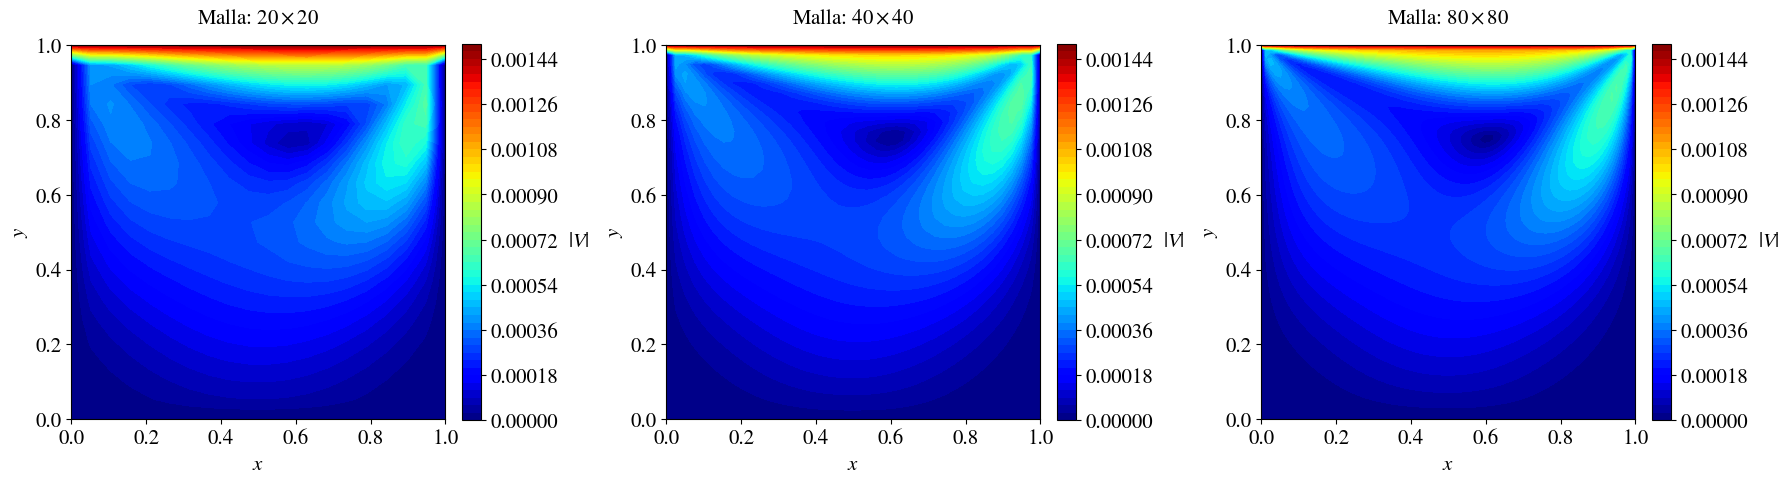

In [ ]:
# Configuramos la figura con un ancho mayor para dar espacio a las barras
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, res in enumerate(N):
    ax = axes[i]

    data_plot = resultados[res]['V']
    data_plot[res-1] = U_wall[0]
    # Aseguramos que X e Y coincidan exactamente con la matriz
    x = np.linspace(0, 1, data_plot.shape[1])
    y = np.linspace(0, 1, data_plot.shape[0])
    X, Y = np.meshgrid(x, y)

    # Gráficos
    cont = ax.contourf(X, Y, data_plot, levels=50, cmap="jet")


    ax.set_aspect('equal', adjustable='box')
    cbar = fig.colorbar(cont, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$|V|$', rotation=0, labelpad=15)

    # Títulos y etiquetas
    ax.set_title(fr'Malla: ${res} \times {res}$', pad=15)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

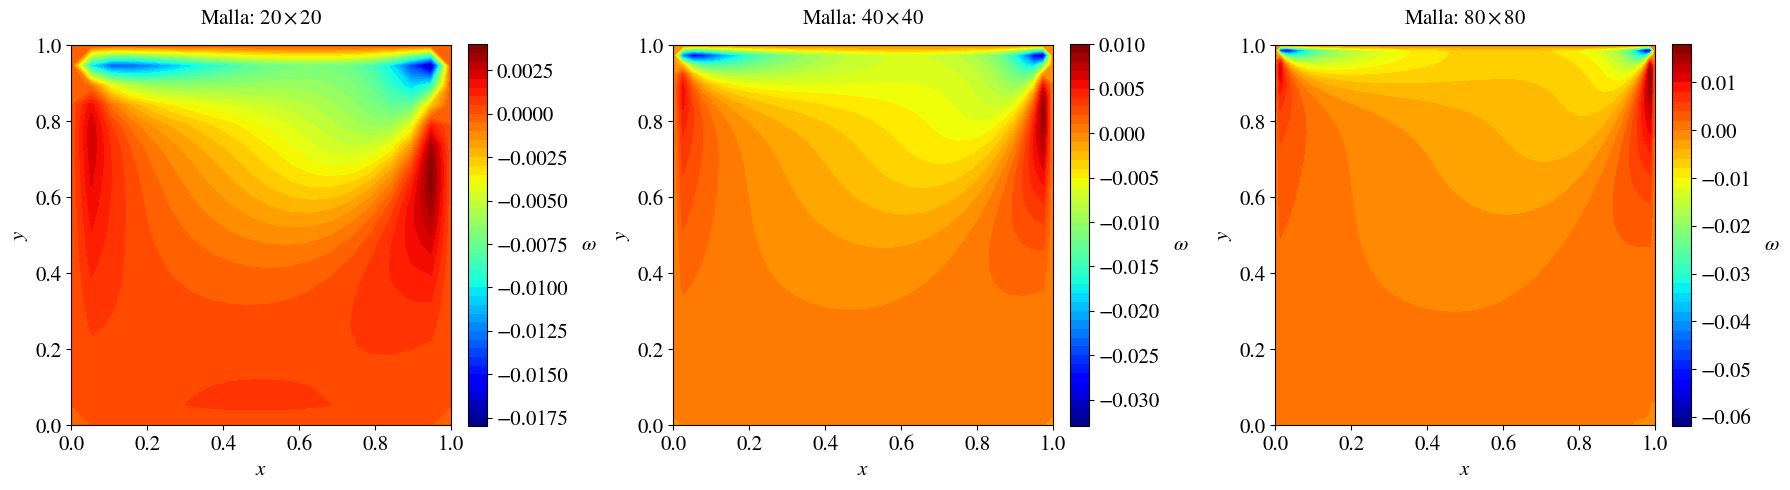

In [ ]:
# Configuramos la figura con un ancho mayor para dar espacio a las barras
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, res in enumerate(N):
    ax = axes[i]

    data_plot = resultados[res]['w']

    # Aseguramos que X e Y coincidan exactamente con la matriz
    x = np.linspace(0, 1, data_plot.shape[1])
    y = np.linspace(0, 1, data_plot.shape[0])
    X, Y = np.meshgrid(x, y)


    # Gráficos
    cont = ax.contourf(X, Y, data_plot, levels=50, cmap="jet")
    #ax.streamplot(X, Y, u, v, color='k', density=1.1, linewidth=0.8)

    ax.set_aspect('equal', adjustable='box')


    cbar = fig.colorbar(cont, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\omega$', rotation=0, labelpad=15)

    # Títulos y etiquetas
    ax.set_title(fr'Malla: ${res} \times {res}$', pad=15)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

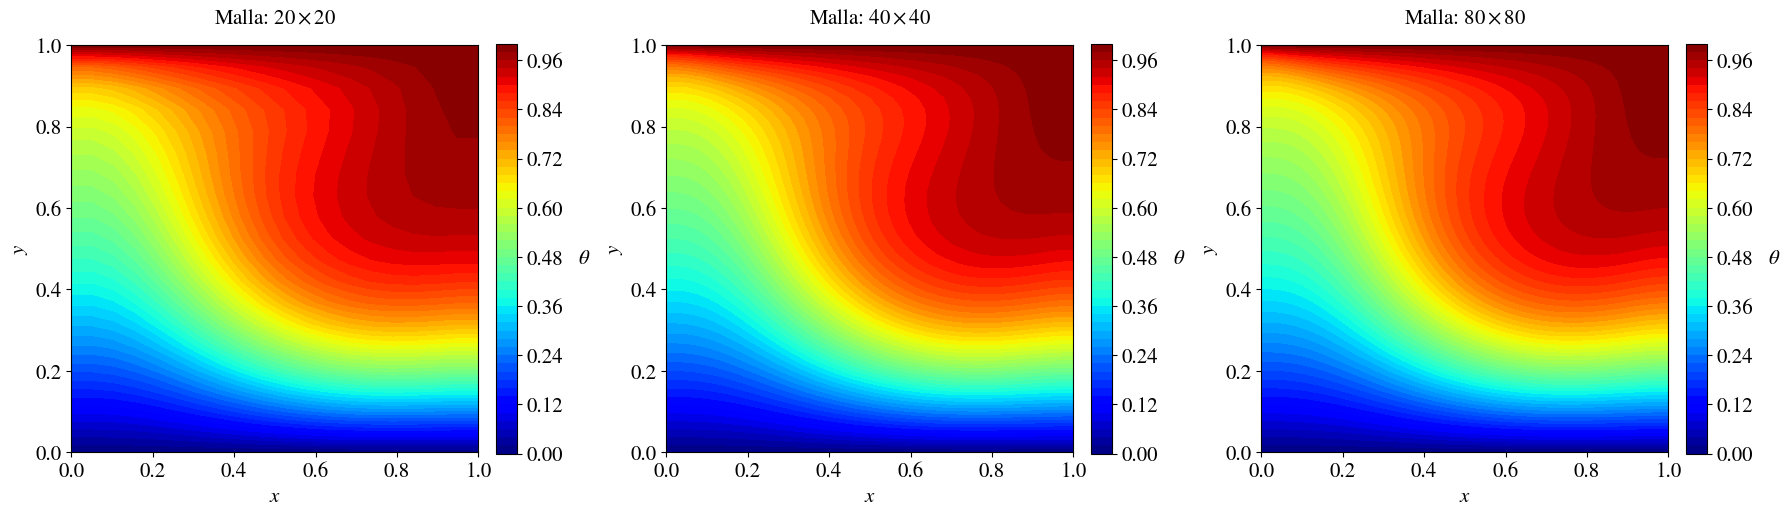

In [ ]:
# Configuramos la figura con un ancho mayor para dar espacio a las barras
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for i, res in enumerate(N):
    ax = axes[i]

    data_plot = resultados[res]['T']
    data_plot[res-1] = 1
    data_plot[:,0] = data_plot[:,1]
    data_plot[:,-1] = data_plot[:,-2]
    # Aseguramos que X e Y coincidan exactamente con la matriz
    x = np.linspace(0, 1, data_plot.shape[1])
    y = np.linspace(0, 1, data_plot.shape[0])
    X, Y = np.meshgrid(x, y)


    # Gráficos
    cont = ax.contourf(X, Y, data_plot, levels=50, cmap="jet")

    ax.set_aspect('equal', adjustable='box')
    cbar = fig.colorbar(cont, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$\theta$', rotation=0, labelpad=15)

    # Títulos y etiquetas
    ax.set_title(fr'Malla: ${res} \times {res}$', pad=15)
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$y$')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [ ]:

data = {
    "y": [
        1.00000, 0.9766, 0.9688, 0.9609, 0.9531, 0.8516, 0.7344, 0.6172,
        0.5000, 0.4531, 0.2813, 0.1719, 0.1016, 0.0703, 0.0625, 0.0547, 0.0000
    ],
    "Re_100": [
        1.00000, 0.84123, 0.78871, 0.73722, 0.68717, 0.23151, 0.00332, -0.13641,
        -0.20581, -0.21090, -0.15662, -0.10150, -0.06434, -0.04775, -0.04192, -0.03717, 0.00000
    ],
    "Re_400": [
        1.00000, 0.75837, 0.68439, 0.61756, 0.55892, 0.29093, 0.16256, 0.02135,
        -0.11477, -0.17119, -0.32726, -0.24299, -0.14612, -0.10338, -0.09266, -0.08186, 0.00000
    ]
}


df_ghia = pd.DataFrame(data)

# Mostrar el DataFrame
print(df_ghia)

         y   Re_100   Re_400
0   1.0000  1.00000  1.00000
1   0.9766  0.84123  0.75837
2   0.9688  0.78871  0.68439
3   0.9609  0.73722  0.61756
4   0.9531  0.68717  0.55892
5   0.8516  0.23151  0.29093
6   0.7344  0.00332  0.16256
7   0.6172 -0.13641  0.02135
8   0.5000 -0.20581 -0.11477
9   0.4531 -0.21090 -0.17119
10  0.2813 -0.15662 -0.32726
11  0.1719 -0.10150 -0.24299
12  0.1016 -0.06434 -0.14612
13  0.0703 -0.04775 -0.10338
14  0.0625 -0.04192 -0.09266
15  0.0547 -0.03717 -0.08186
16  0.0000  0.00000  0.00000


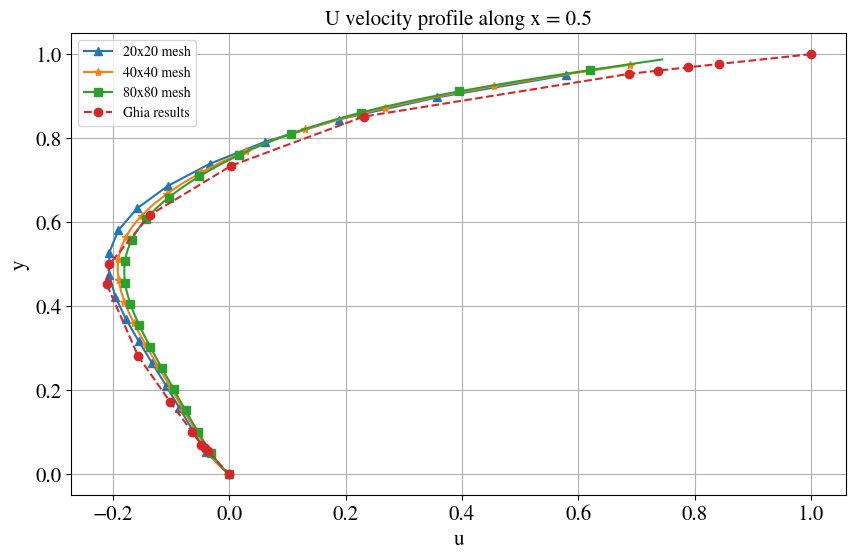

In [ ]:
plt.figure(figsize=(10, 6))
for i, res in enumerate(N):
  u = resultados[res]["u"]
  u_validacion = u[:-1,int(res/2)]/U_wall[0]
  dy = 1 - 1/res
  y = np.linspace(0, dy , u_validacion.shape[0])
  if res == 20:
    m_step = 1
    m = "^"
  elif res == 40:
    m_step = 2
    m = "*"
  elif res == 80:
    m_step = 4
    m = "s"
  plt.plot(u_validacion, y, label=f"{res}x{res} mesh", marker = m , markevery=m_step)


plt.plot(df_ghia["Re_100"], df_ghia["y"], marker = "o", linestyle = "--",label = "Ghia results")
plt.ylabel("y")
plt.xlabel("u")
plt.grid()
plt.legend()
plt.title("U velocity profile along x = 0.5")
plt.show()


In [ ]:
resultados[20]['nu_prom']

np.float64(1.8860877268724654)

<>:11: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_3167/2918253696.py:11: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("$\overline{Nu}$")
/tmp/ipykernel_3167/2918253696.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


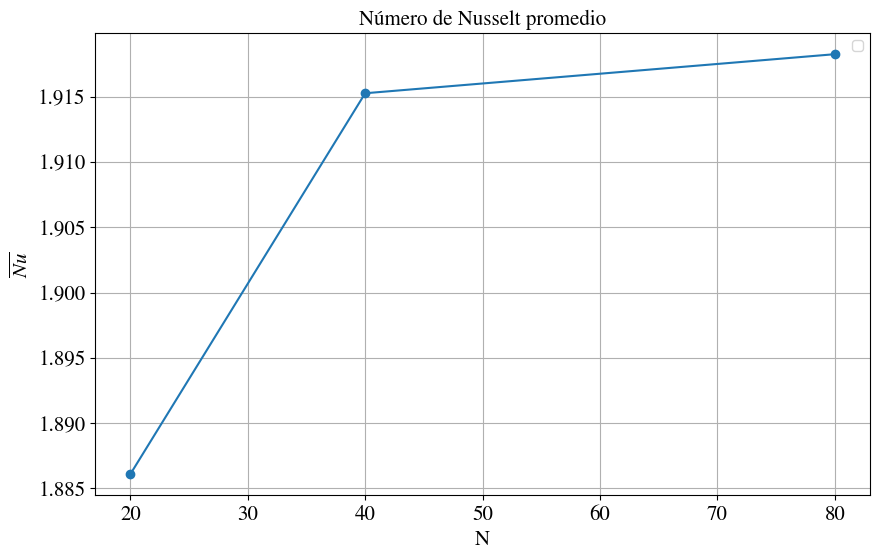

In [ ]:
plt.figure(figsize=(10, 6))
nus = []
for i, res in enumerate(N):
  nus.append(resultados[res]['nu_prom'])


plt.plot(N, nus, marker = "o")


#plt.plot(df_ghia["Re_100"], df_ghia["y"], marker = "o", linestyle = "--",label = "Ghia Cavity code")
plt.ylabel(r"$\overline{Nu}$")
plt.xlabel("N")
plt.grid()
plt.legend()
plt.title("Número de Nusselt promedio")
plt.show()

In [ ]:
nu_diff = [nus[i+1]-nus[i] for i in range(len(nus)-1)]

In [ ]:
print(nu_diff)

[np.float64(0.02918494674176131), np.float64(0.00299233486073458)]


In [ ]:
import matplotlib.pyplot as plt

# Crear figura
fig, ax = plt.subplots()

# Dibujar celda izquierda
ax.plot([0, 1, 1, 0, 0], [0, 0, 1, 1, 0])
ax.text(0.5, 1.05, r'Celda izquierda ($\psi_l$)',
        ha='center', va='center')

# Dibujar celda derecha
ax.plot([1, 2, 2, 1, 1], [0, 0, 1, 1, 0])
ax.text(1.5, 1.05, r'Celda derecha ($\psi_r$)',
        ha='center', va='center')

# Cara compartida
ax.plot([1, 1], [0, 1], label = "Cara/lado compartido")

# Vector normal (sin especificar color)
ax.arrow(1, 0.5, 0.4, 0,
         head_width=0.08,
         length_includes_head=True)

# Etiqueta del vector normal
ax.text(1.25, 0.65, r'$n$', ha='center')

# Centroides
ax.plot(0.5, 0.5, 'o')
ax.plot(1.5, 0.5, 'o')

# Distancia Δn
ax.annotate(
    '',
    xy=(1.5, 0.2),
    xytext=(0.5, 0.2),
    arrowprops=dict(arrowstyle='<->')
)
ax.text(1.0, 0.1, r'$\Delta n$', ha='center')

# Ajustes visuales
ax.set_aspect('equal')
ax.set_xlim(-0.2, 2.2)
ax.set_ylim(-0.2, 1.2)
ax.axis('off')

# Guardar imagen (opcional)
plt.savefig("celdas_izquierda_derecha.png", dpi=300, bbox_inches='tight')
plt.legend()
# Mostrar
plt.show()

In [ ]:
u_final400, v_final400, w_final400, phi_final400, T_final400, u_history400, v_history400, iter_num400, diff_num400 = solver(N[1], U_wall[1], cells400, dx40)

Iter global: 1, diff: 3.96e+04
Iter global: 2, diff: 1.09e+00
Iter global: 3, diff: 1.80e+01
Iter global: 4, diff: 3.22e+01
Iter global: 5, diff: 6.17e+00
Iter global: 6, diff: 3.00e+00
Iter global: 7, diff: 5.06e+00
Iter global: 8, diff: 6.09e-01
Iter global: 9, diff: 1.82e+00
Iter global: 10, diff: 7.84e-01
Iter global: 11, diff: 3.41e-01
Iter global: 12, diff: 2.16e-01
Iter global: 13, diff: 1.79e-01
Iter global: 14, diff: 1.51e-01
Iter global: 15, diff: 1.21e-01
Iter global: 16, diff: 9.34e-02
Iter global: 17, diff: 6.91e-02
Iter global: 18, diff: 4.96e-02
Iter global: 19, diff: 3.48e-02
Iter global: 20, diff: 2.40e-02
Iter global: 21, diff: 1.64e-02
Iter global: 22, diff: 1.11e-02
Iter global: 23, diff: 7.45e-03
Iter global: 24, diff: 4.98e-03
Iter global: 25, diff: 3.33e-03
Iter global: 26, diff: 2.22e-03
Iter global: 27, diff: 1.47e-03
Iter global: 28, diff: 9.80e-04
Iter global: 29, diff: 6.51e-04
Iter global: 30, diff: 4.32e-04
Iter global: 31, diff: 2.87e-04
Iter global: 32, 

In [ ]:
resultados2 = {}
finals = [40,400]

for u in finals:
    # 1. Acceder dinámicamente a los datos originales
    # (Asumiendo que están en el namespace global, aunque lo ideal es tenerlos en una lista)
    u_raw = globals()[f'u_final{u}']
    v_raw = globals()[f'v_final{u}']
    phi_raw = globals()[f'phi_final{u}']
    T_raw = globals()[f'T_final{u}']
    dx = globals()[f'dx40']
    w = globals()[f'w_final{u}']
    #n_size = N_map[res]

    # 2. Procesar y guardar en el diccionario
    resultados2[u] = {
        'u': np.array(u_raw).reshape(40, 40),
        'v': np.array(v_raw).reshape(40, 40),
        'phi': np.array(phi_raw).reshape(40, 40),
        'T': np.array(T_raw).reshape(40, 40),
        'w': np.array(w).reshape(40, 40)

    }

    # 3. Calcular Nusselt
    nu_prom2, nu_loc2 = nusselt_prom(resultados2[u]['T'], 1/40)
    resultados2[u]['nu_prom'] = nu_prom2
    resultados2[u]['nu_loc'] = nu_loc2

    # CALCULO MAGNITUD VELocidad
    resultados2[u]['V'] = np.sqrt(resultados2[u]['u']**2 + resultados2[u]['v']**2)

## Re_100

Text(0, 0.5, '$|V|$')

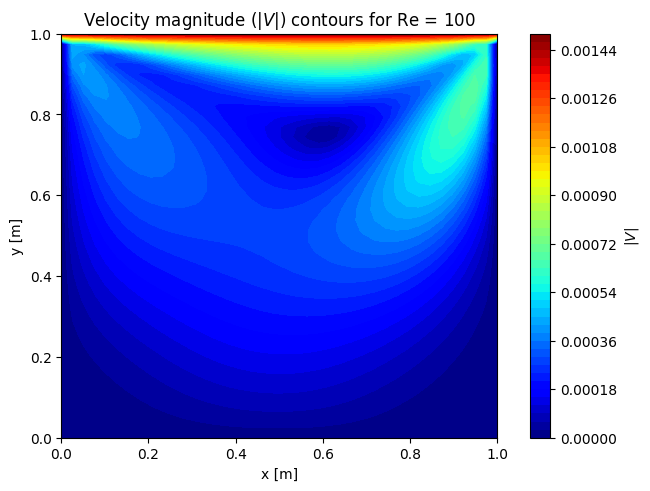

In [ ]:
fig1, ax2 = plt.subplots(layout='constrained')

data_plot = resultados2[40]['V']
data_plot[40-1] = U_wall[0]

x = np.linspace(0, 1, data_plot.shape[1])
y = np.linspace(0, 1, data_plot.shape[0])
X, Y = np.meshgrid(x, y)


CS = ax2.contourf(X,Y, data_plot, cmap="jet", levels = 50)
ax2.set_title("Velocity magnitude ($|V|$) contours for Re = 100")
ax2.set_xlabel('x [m]')
ax2.set_ylabel('y [m]')
cbar = fig1.colorbar(CS)
cbar.ax.set_ylabel('$|V|$')

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1168/517312027.py:17: SyntaxWarning: invalid escape sequence '\p'
  cbar.ax.set_ylabel('$\psi$')


Text(0, 0.5, '$\\psi$')

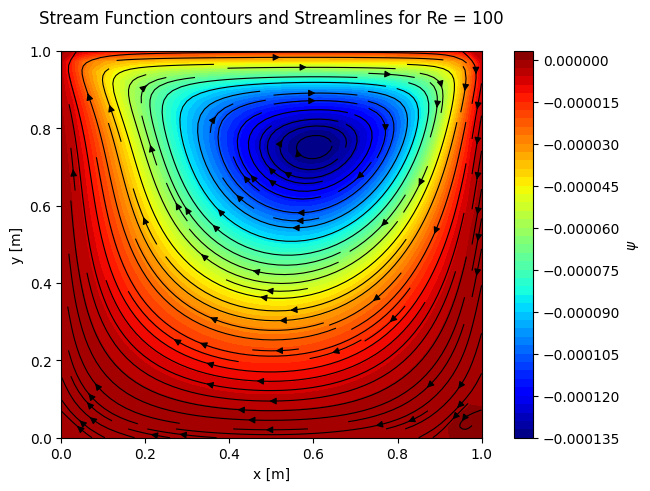

In [ ]:
fig1, ax2 = plt.subplots(layout='constrained')

data_plot = resultados2[40]['phi']
#data_plot[40-1] = U_wall[0]

x = np.linspace(0, 1, data_plot.shape[1])
y = np.linspace(0, 1, data_plot.shape[0])
X, Y = np.meshgrid(x, y)
u = resultados2[40]['u']
v = resultados2[40]['v']
ax2.streamplot(X, Y, u, v, color='k', density=1.5, linewidth=0.8)
CS = ax2.contourf(X,Y, data_plot, cmap="jet", levels = 50)
ax2.set_title("Stream Function contours and Streamlines for Re = 100", pad =20)
ax2.set_xlabel('x [m]')
ax2.set_ylabel('y [m]')
cbar = fig1.colorbar(CS)
cbar.ax.set_ylabel(r'$\psi$')

Text(0, 0.5, '$\\ \\theta $')

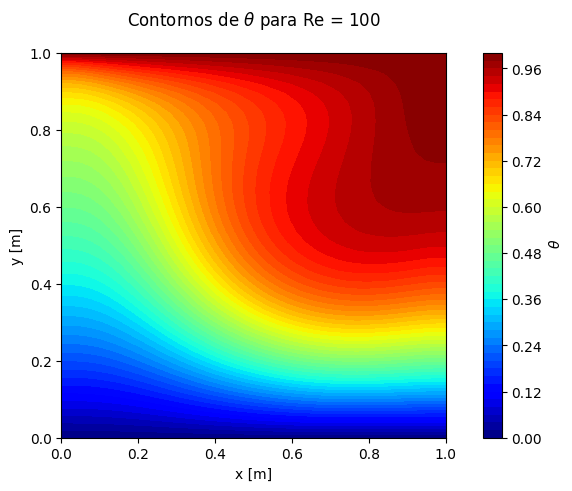

In [ ]:
fig1, ax2 = plt.subplots(layout='constrained')

data_plot = resultados2[40]['T']
data_plot[40-1] = 1
data_plot[:,0] = data_plot[:,1]
data_plot[:,-1] = data_plot[:,-2]

x = np.linspace(0, 1, data_plot.shape[1])
y = np.linspace(0, 1, data_plot.shape[0])
X, Y = np.meshgrid(x, y)

CS = ax2.contourf(X,Y, data_plot, cmap="jet", levels = 50)
ax2.set_title(r"Contornos de $\theta$ para Re = 100", pad =20)
ax2.set_xlabel('x [m]')
ax2.set_ylabel('y [m]')
ax2.set_aspect('equal', adjustable='box')

cbar = fig1.colorbar(CS)
cbar.ax.set_ylabel(r'$\ \theta $')

## Re_400

Text(0, 0.5, '$|V|$')

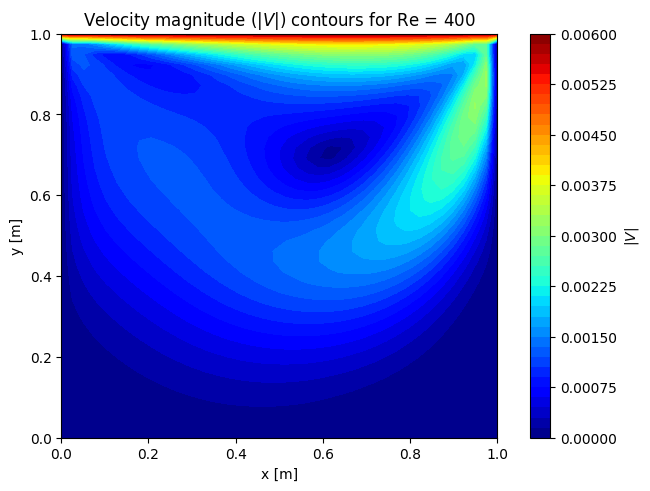

In [ ]:
fig1, ax2 = plt.subplots(layout='constrained')

data_plot = resultados2[400]['V']
data_plot[40-1] = U_wall[1]


CS = ax2.contourf(X,Y, data_plot, cmap="jet", levels = 50)
ax2.set_title("Velocity magnitude ($|V|$) contours for Re = 400")
ax2.set_xlabel('x [m]')
ax2.set_ylabel('y [m]')
cbar = fig1.colorbar(CS)
cbar.ax.set_ylabel('$|V|$')

<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_1168/1267020952.py:17: SyntaxWarning: invalid escape sequence '\p'
  cbar.ax.set_ylabel('$\psi$')


Text(0, 0.5, '$\\psi$')

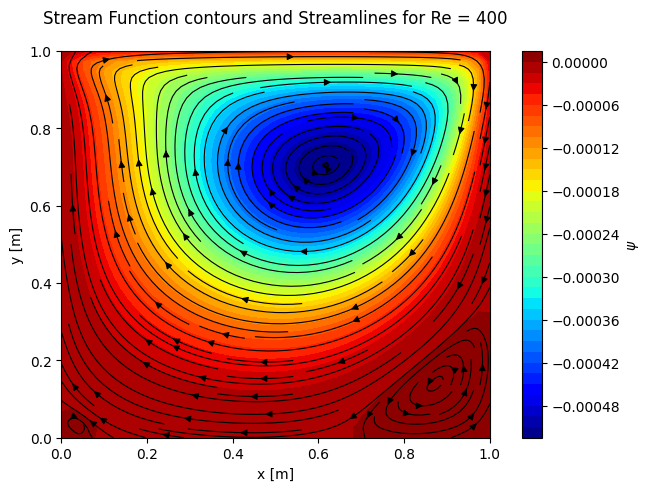

In [ ]:
fig1, ax2 = plt.subplots(layout='constrained')

data_plot = resultados2[400]['phi']
#data_plot[40-1] = U_wall[0]

x = np.linspace(0, 1, data_plot.shape[1])
y = np.linspace(0, 1, data_plot.shape[0])
X, Y = np.meshgrid(x, y)
u = resultados2[400]['u']
v = resultados2[400]['v']
ax2.streamplot(X, Y, u, v, color='k', density=1.5, linewidth=0.8)
CS = ax2.contourf(X,Y, data_plot, cmap="jet", levels = 50)
ax2.set_title("Stream Function contours and Streamlines for Re = 400", pad =20)
ax2.set_xlabel('x [m]')
ax2.set_ylabel('y [m]')
cbar = fig1.colorbar(CS)
cbar.ax.set_ylabel(r'$\psi$')

<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_1168/2809207774.py:15: SyntaxWarning: invalid escape sequence '\o'
  cbar.ax.set_ylabel('$\omega$')


Text(0, 0.5, '$\\omega$')

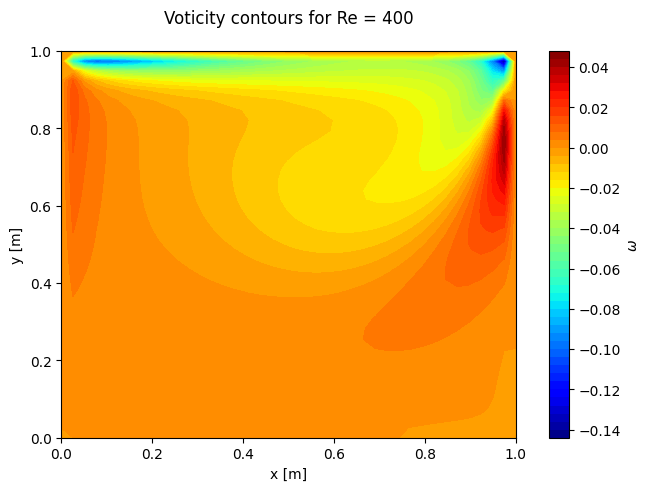

In [ ]:
fig1, ax2 = plt.subplots(layout='constrained')

data_plot = resultados2[400]["w"]
#data_plot[40-1] = U_wall[0]

x = np.linspace(0, 1, data_plot.shape[1])
y = np.linspace(0, 1, data_plot.shape[0])
X, Y = np.meshgrid(x, y)

CS = ax2.contourf(X,Y, data_plot, cmap="jet", levels = 50)
ax2.set_title("Voticity contours for Re = 400", pad =20)
ax2.set_xlabel('x [m]')
ax2.set_ylabel('y [m]')
cbar = fig1.colorbar(CS)
cbar.ax.set_ylabel(r'$\omega$')

Text(0, 0.5, '$\\theta$')

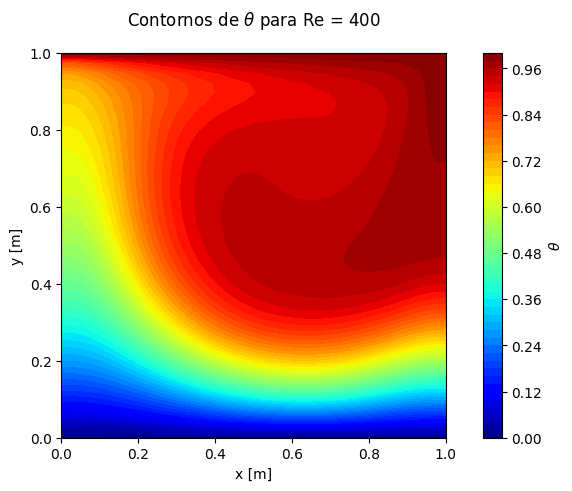

In [ ]:
fig1, ax2 = plt.subplots(layout='constrained')

data_plot = resultados2[400]['T']
data_plot[40-1] = 1
data_plot[:,0] = data_plot[:,1]
data_plot[:,-1] = data_plot[:,-2]

x = np.linspace(0, 1, data_plot.shape[1])
y = np.linspace(0, 1, data_plot.shape[0])
X, Y = np.meshgrid(x, y)

CS = ax2.contourf(X,Y, data_plot, cmap="jet", levels = 50)
ax2.set_title(r"Contornos de $\theta$ para Re = 400", pad =20)
ax2.set_xlabel('x [m]')
ax2.set_ylabel('y [m]')
ax2.set_aspect('equal', adjustable='box')
cbar = fig1.colorbar(CS)
cbar.ax.set_ylabel(r'$\theta$')

Validación

In [ ]:
# DATOS DE GHIA para vortice primatio
psi_mins_ghia = np.array([-0.103423, -0.113909])
w_mins_ghia = np.array([3.16646, 2.29469])
x_mins_ghia = np.array([0.6172, 0.5547])
y_mins_ghia = np.array([0.7344, 0.6055])

psi_mins_own = []
w_mins_own = []
x_mins_own = []
y_mins_own = []


min_psi100 = np.min(resultados2[40]["phi"])
min_psi400 = np.min(resultados2[400]["phi"])

id_100 = np.where(resultados2[40]["phi"] == min_psi100)
id_400 = np.where(resultados2[400]["phi"] == min_psi400)

print(id_100)
print(id_400)


(array([29]), array([23]))
(array([27]), array([24]))


In [ ]:
np.max(resultados2[400]["phi"])

np.float64(2.7153366175086613e-06)

In [ ]:

cell_min100 = min(cells40, key=lambda c: c.phi)
psi_mins_own.append(min_psi100/U_wall[0])
w_mins_own.append(cell_min100.w)

x_mins_own.append(cell_min100.centroid[0])
y_mins_own.append(cell_min100.centroid[1])


psi_400 = resultados2[400]['phi']/U_wall[1]
cell_min400 = min(cells400, key=lambda c: c.phi)
psi_mins_own.append(cell_min400.phi)
w_mins_own.append(cell_min400.w)

x_mins_own.append(cell_min400.centroid[0])
y_mins_own.append(cell_min400.centroid[1])

error_psi = np.abs(psi_mins_ghia - psi_mins_own)/psi_mins_ghia
error_w = np.abs(w_mins_ghia - w_mins_own)/w_mins_ghia * 100
error_x = np.abs(x_mins_ghia - x_mins_own)/x_mins_ghia * 100
error_y = np.abs(y_mins_ghia - y_mins_own)/y_mins_ghia * 100
print(y_mins_own, y_mins_ghia)
print(x_mins_own, x_mins_ghia)
print(error_x)
print(error_y)

[np.float64(0.7375), np.float64(0.6875000000000001)] [0.7344 0.6055]
[np.float64(0.5875000000000001), np.float64(0.6125)] [0.6172 0.5547]
[ 4.81205444 10.42004687]
[ 0.42211329 13.54252684]


In [ ]:

data_v = [
    [129, 1.0000, 0.00000, 0.00000],
    [125, 0.9688, -0.05906, -0.12146],
    [124, 0.9609, -0.07391, -0.15663],
    [123, 0.9531, -0.08864, -0.19254],
    [122, 0.9453, -0.10313, -0.22847],
    [117, 0.9063, -0.16914, -0.23827],
    [111, 0.8594, -0.22445, -0.44993],
    [104, 0.8047, -0.24533, -0.38598],
    [65,  0.5000,  0.05454,  0.05186],
    [31,  0.2344,  0.17527,  0.30174],
    [30,  0.2266,  0.17507,  0.30203],
    [21,  0.1563,  0.16077,  0.28124],
    [13,  0.0938,  0.12317,  0.22965],
    [11,  0.0781,  0.10890,  0.20920],
    [10,  0.0703,  0.10091,  0.19713],
    [9,   0.0625,  0.09233,  0.18360],
    [1,   0.0000,  0.00000,  0.00000],
]

df_v = pd.DataFrame(data_v, columns=["grid_pt_no", "x", "100", "400"])

In [ ]:
import pandas as pd

data_u = [
    [129, 1.0000, 1.00000, 1.00000],
    [126, 0.9766, 0.84123, 0.75837],
    [125, 0.9688, 0.78871, 0.68439],
    [124, 0.9609, 0.73722, 0.61756],
    [123, 0.9531, 0.68717, 0.55892],
    [110, 0.8516, 0.23151, 0.29093],
    [95,  0.7344, 0.00332, 0.16256],
    [80,  0.6172, -0.13641, 0.02135],
    [65,  0.5000, -0.20581, -0.11477],
    [59,  0.4531, -0.21090, -0.17119],
    [37,  0.2813, -0.15662, -0.32726],
    [23,  0.1719, -0.10150, -0.24299],
    [14,  0.1016, -0.06434, -0.14612],
    [10,  0.0703, -0.04775, -0.10338],
    [9,   0.0625, -0.04192, -0.09266],
    [8,   0.0547, -0.03717, -0.08186],
    [1,   0.0000, 0.00000, 0.00000],
]

df_u = pd.DataFrame(data_u, columns=["grid_pt_no", "y", "100", "400"])

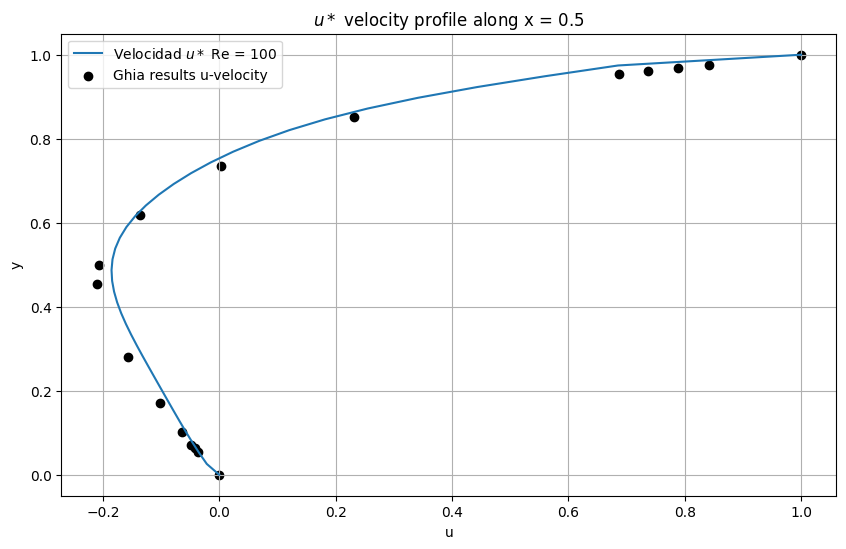

In [ ]:
plt.figure(figsize=(10, 6))


u40 = resultados2[40]["u"]
y = np.linspace(0, 1, u40.shape[0])
u40_validacion = u40[:-1,int(19)]/U_wall[0]
xu = resultados2[40]["u"]
xu[-1,19] = U_wall[0]
xu_val = xu[:-1,int(19)]/U_wall[0]
#plt.plot(u40_validacion, y[:-1],linestyle = "--")
plt.plot(xu[:,19]/U_wall[0], y, label=f"Velocidad $u*$ Re = 100")
plt.scatter(df_u["100"], df_u["y"], marker = "o",label = "Ghia results u-velocity", color = "k")

plt.ylabel("y")
plt.xlabel("u")
plt.grid()
plt.legend()
plt.title("$u*$ velocity profile along x = 0.5")
plt.show()


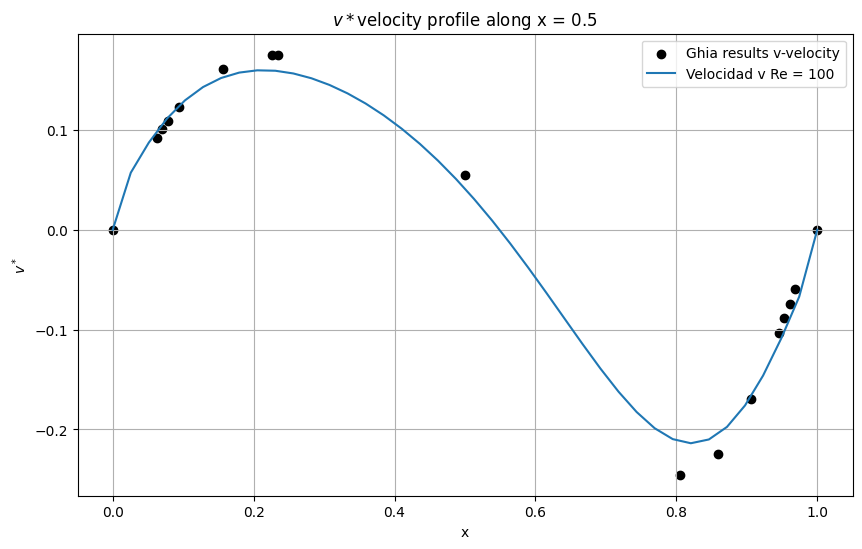

In [ ]:
plt.figure(figsize=(10, 6))
v100 = resultados2[40]["v"]
v_validacion = v100[:][int(40/2)]/U_wall[0]
x = np.linspace(0,1,40)
plt.scatter(df_v['x'],df_v["100"],  label = "Ghia results v-velocity", color = "k")
plt.plot(x, v_validacion, label=f"Velocidad v Re = 100")
plt.title("$v*$velocity profile along x = 0.5")
plt.ylabel(r"$v^*$")
plt.xlabel("x")
plt.grid()
plt.legend()
plt.show()

In [ ]:
u = resultados2[400]["u"][39]
print(u)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


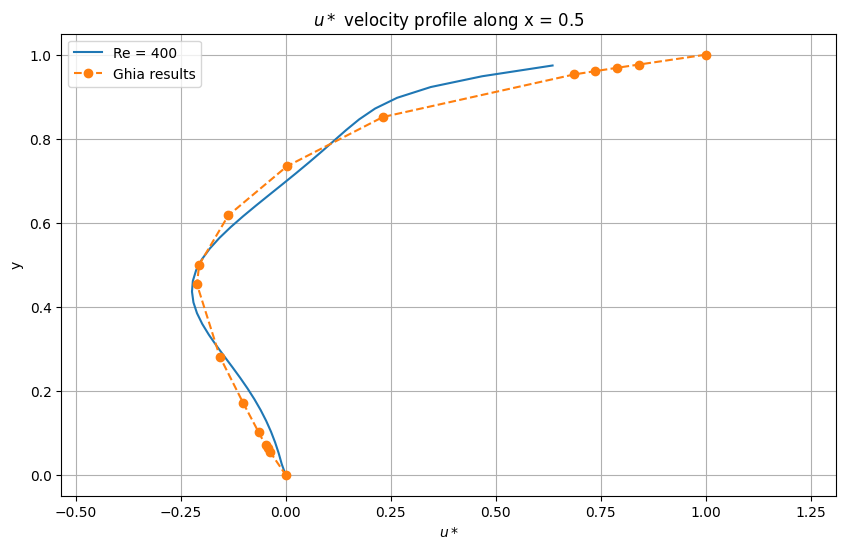

In [ ]:
plt.figure(figsize=(10, 6))
u = resultados2[400]["u"]
u_validacion = u[:-1,int(40/2 -1)]/U_wall[1]
plt.plot(u_validacion, y[:-1], label=f"Re = 400")
plt.plot(df_u["100"], df_u["y"], marker = "o", linestyle = "--",label = "Ghia results")
plt.ylabel("y")
plt.xlabel("$u*$")
plt.grid()
plt.legend()
plt.title("$u*$ velocity profile along x = 0.5")
plt.axis('equal')
plt.show()


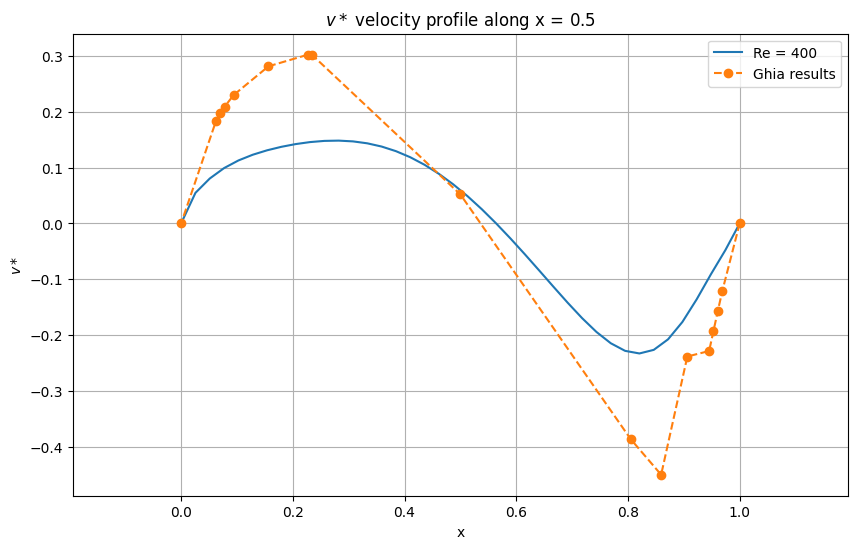

In [ ]:
plt.figure(figsize=(10, 6))
v400 = resultados2[400]["v"]
v400_validacion = v400[:][int(40/2 -1)]/U_wall[1]
plt.plot( x,v400_validacion, label=f"Re = 400")
plt.plot( df_v["x"],df_v["400"], marker = "o", linestyle = "--",label = "Ghia results")
plt.xlabel("x")
plt.ylabel("$v*$")
plt.grid()
plt.legend()
plt.title("$v*$ velocity profile along x = 0.5")
plt.axis('equal')
plt.show()


In [ ]:
u_final80, v_final80, w_final80, phi_final80, T_final80, u_history80, v_history80, iter_num80, diff_num80 = solver(N[2], U_wall[1], cells80, dx80)

u_400_fine = np.array(u_final80).reshape(80, 80)
v_400_fine = np.array(v_final80).reshape(80, 80)
phi_400_fine = np.array(phi_final80).reshape(80, 80)
T_400_fine =  np.array(T_final80).reshape(80, 80)
w_400_fine =  np.array(w_final80).reshape(80, 80)
#
V = np.sqrt(u_400_fine**2 + v_400_fine**2)

NameError: name 'u_final80' is not defined

In [ ]:
fig1, ax2 = plt.subplots(layout='constrained')

x = np.linspace(0,1,80)
y = np.linspace(0,1,80)
X, Y = np.meshgrid(x, y)

CS = ax2.contourf(X,Y, V, cmap="jet", levels = 50)
ax2.set_title("Velocity magnitude ($|V|$) contours for Re = 400")
ax2.set_xlabel('x [m]')
ax2.set_ylabel('y [m]')
cbar = fig1.colorbar(CS)
cbar.ax.set_ylabel('$|V|$')
ax2.set_aspect('equal', adjustable='box')
#

In [ ]:
fig1, ax2 = plt.subplots(layout='constrained')

#data_plot[40-1] = U_wall[0]
ax2.streamplot(X, Y, u_400_fine, v_400_fine, color='k', density=1.5, linewidth=0.8)
CS = ax2.contourf(X,Y, phi_400_fine, cmap="jet", levels = 50)
ax2.set_title("Stream Function contours and Streamlines for Re = 400", pad =20)
ax2.set_xlabel('x [m]')
ax2.set_ylabel('y [m]')
cbar = fig1.colorbar(CS)
cbar.ax.set_ylabel(r'$\psi$')
ax2.set_aspect('equal', adjustable='box')
#

In [ ]:
fig1, ax2 = plt.subplots(layout='constrained')


CS = ax2.contourf(X,Y, w_400_fine, cmap="jet", levels = 50)
ax2.set_title("Voticity contours for Re = 400", pad =20)
ax2.set_xlabel('x [m]')
ax2.set_ylabel('y [m]')
cbar = fig1.colorbar(CS)
cbar.ax.set_ylabel(r'$\omega$')
ax2.set_aspect('equal', adjustable='box')
#

In [ ]:
fig1, ax2 = plt.subplots(layout='constrained')
T_400_fine_plot = T_400_fine
T_400_fine_plot[80-1] = 1
T_400_fine_plot[:,0] = T_400_fine_plot[:,1]
T_400_fine_plot[:,-1] = T_400_fine_plot[:,-2]

CS = ax2.contourf(X,Y, T_400_fine_plot, cmap="jet", levels = 50)
ax2.set_title("Temperature contours for Re = 400", pad =20)
ax2.set_xlabel('x [m]')
ax2.set_ylabel('y [m]')
cbar = fig1.colorbar(CS)
cbar.ax.set_ylabel(r'$\theta$')
ax2.set_aspect('equal', adjustable='box')
#

In [ ]:
plt.figure(figsize=(10, 6))
v400 = resultados2[400]["v"]
v400_validacion = v400[:][int(40/2 -1)]/U_wall[1]

v_fine = v_400_fine[:][int(80/2 -1)]/U_wall[1]
x1 = np.linspace(0,1,80)
x2 = np.linspace(0,1,40)

plt.plot( x2,v400_validacion, label=f"Re = 400")
plt.plot( x1,v_fine, label=f"Re = 400 fine mesh")
plt.scatter( df_v["x"],df_v["400"], label = "Ghia results", color = "k")
plt.xlabel("x")
plt.ylabel("$v*$")
plt.grid()
plt.legend()
plt.title("$v*$ velocity profile along x = 0.5")
plt.axis('equal')
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))
u = resultados2[400]["u"]
u[-1,19] = U_wall[1]
u_validacion = u[:,int(40/2 -1)]/U_wall[1]
u_400_fine[-1,39] = U_wall[1]
u_fine = u_400_fine[:,int(80/2 -1)]/U_wall[1]
y1 = np.linspace(0,1,80)
y2 = np.linspace(0,1,40)

plt.plot(u_validacion, y2, label=f"Re = 400")
plt.plot(u_fine, y1, label=f"Re = 400 fine mesh")
plt.scatter(df_u["100"], df_u["y"],label = "Ghia results", color = "k")
plt.ylabel("y")
plt.xlabel("$u*$")
plt.grid()
plt.legend()
plt.title("$u*$ velocity profile along x = 0.5")
plt.axis('equal')
plt.show()


In [ ]:
# Load validation CSV files exported from Fluent.
# In Google Colab this opens an upload widget; outside Colab (e.g. running
# locally after cloning from GitHub), place the CSV files in the working
# directory instead and this cell will just skip the widget.
try:
    from google.colab import files
    uploaded = files.upload()
except ImportError:
    print("Not running in Google Colab: skipping the upload widget.")
    print("Make sure 'u_x05.csv', 'u_x05_400.csv', 'v_x05.csv' and 'v_x05400.csv' are in the working directory.")


Saving u_x05.csv to u_x05.csv
Saving u_x05_400.csv to u_x05_400.csv
Saving v_x05.csv to v_x05.csv
Saving v_x05400.csv to v_x05400.csv


In [ ]:
u_x05_fluent = pd.read_csv('u_x05.csv')
u_x05_400_fluent = pd.read_csv('u_x05_400.csv')

v_x05_fluent = pd.read_csv('v_x05.csv')
v_x05_400_fluent = pd.read_csv('v_x05400.csv')


In [ ]:
u_x05_fluent.head()

,Velocity u [ m s^-1 ],Y [ m ]
0,0.000000,0.000000
1,-0.000027,0.025641
2,-0.000051,0.051282
3,-0.000073,0.076923
4,-0.000095,0.102564


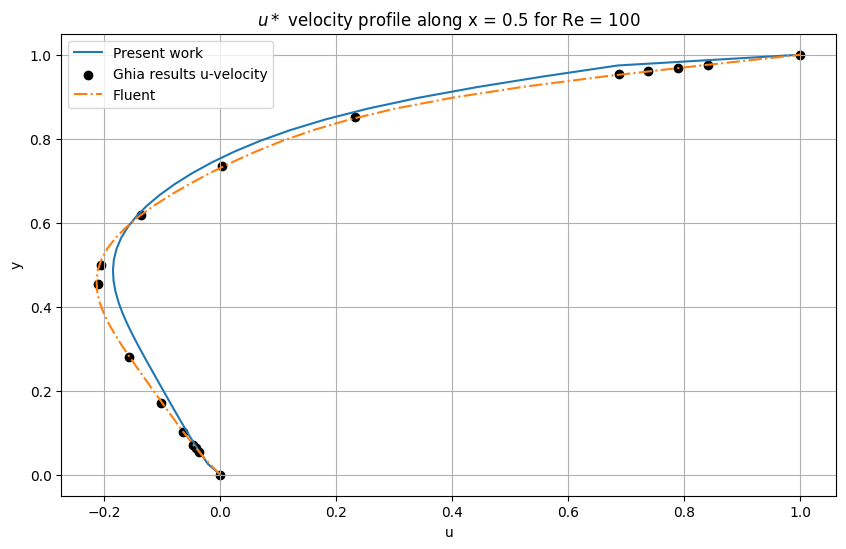

In [ ]:
plt.figure(figsize=(10, 6))


u40 = resultados2[40]["u"]
y = np.linspace(0, 1, u40.shape[0])
u40_validacion = u40[:-1,int(19)]/U_wall[0]
xu = resultados2[40]["u"]
xu[-1,19] = U_wall[0]
xu_val = xu[:-1,int(19)]/U_wall[0]
#plt.plot(u40_validacion, y[:-1],linestyle = "--")

plt.plot(xu[:,19]/U_wall[0], y, label=f"Present work")
plt.scatter(df_u["100"], df_u["y"], marker = "o",label = "Ghia results u-velocity", color = "k")
plt.plot(u_x05_fluent['Velocity u [ m s^-1 ]']/U_wall[0], u_x05_fluent['Y [ m ]'], label = "Fluent", linestyle = "-.")


plt.ylabel("y")
plt.xlabel("u")
plt.grid()
plt.legend()
plt.title("$u*$ velocity profile along x = 0.5 for Re = 100")
plt.show()


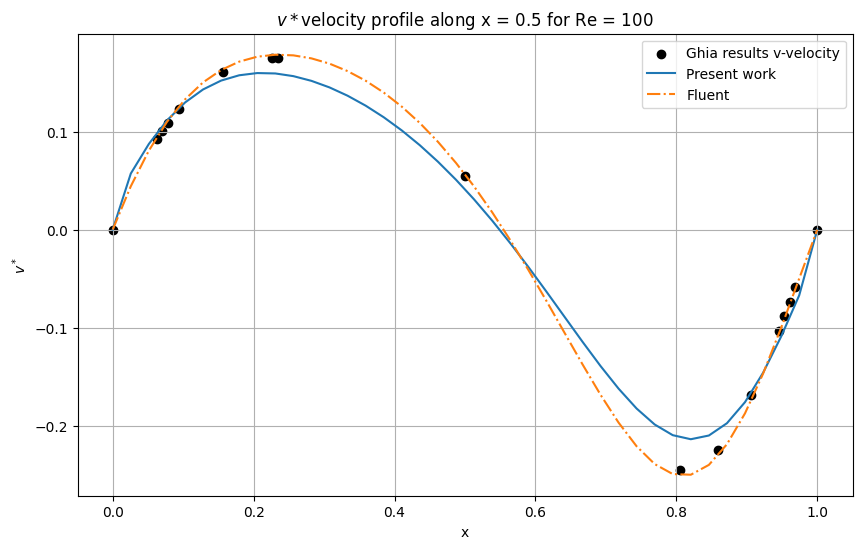

In [ ]:
plt.figure(figsize=(10, 6))
v100 = resultados2[40]["v"]
v_validacion = v100[:][int(40/2)]/U_wall[0]
x = np.linspace(0,1,40)
plt.scatter(df_v['x'],df_v["100"],  label = "Ghia results v-velocity", color = "k")
plt.plot(x, v_validacion, label=f"Present work")
plt.plot(v_x05_fluent['X [ m ]'], v_x05_fluent['Velocity v [ m s^-1 ]']/U_wall[0], label = "Fluent", linestyle = "-.")


plt.title("$v*$velocity profile along x = 0.5 for Re = 100")
plt.ylabel(r"$v^*$")
plt.xlabel("x")
plt.grid()
plt.legend()
plt.show()

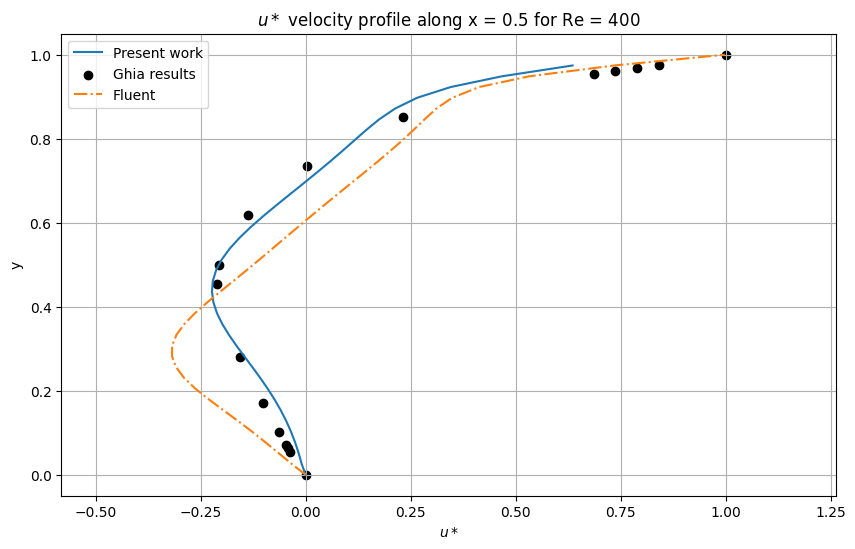

In [ ]:
plt.figure(figsize=(10, 6))
u = resultados2[400]["u"]
u_validacion = u[:-1,int(40/2 -1)]/U_wall[1]
plt.plot(u_validacion, y[:-1], label=f"Present work")
plt.scatter(df_u["100"], df_u["y"], label = "Ghia results", color = "k")
plt.plot(u_x05_400_fluent['Velocity u [ m s^-1 ]']/U_wall[1], u_x05_400_fluent['Y [ m ]'], label = "Fluent", linestyle = "-.")

plt.ylabel("y")
plt.xlabel("$u*$")
plt.grid()
plt.legend()
plt.title("$u*$ velocity profile along x = 0.5 for Re = 400")
plt.axis('equal')
plt.show()


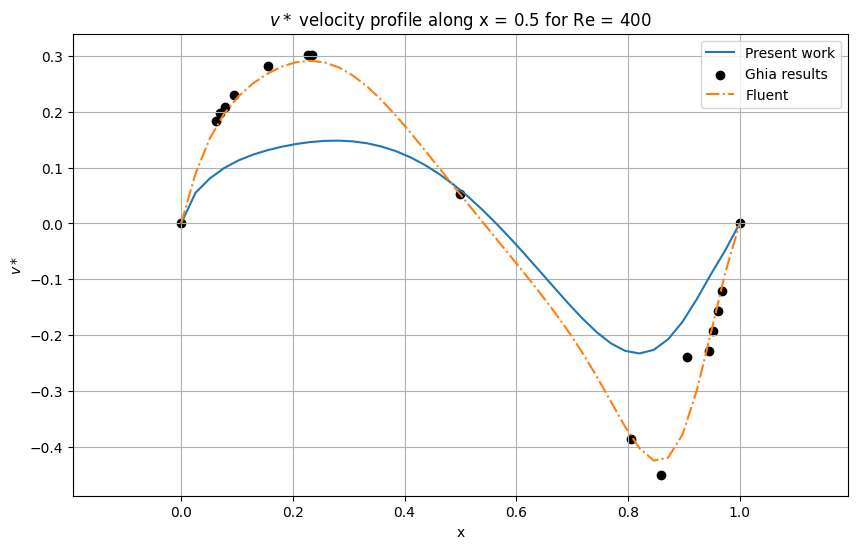

In [ ]:
plt.figure(figsize=(10, 6))
v400 = resultados2[400]["v"]
v400_validacion = v400[:][int(40/2 -1)]/U_wall[1]
plt.plot( x,v400_validacion, label=f"Present work")
plt.scatter( df_v["x"],df_v["400"], label = "Ghia results", color = "k")
plt.plot(v_x05_400_fluent['X [ m ]'],v_x05_400_fluent['Velocity v [ m s^-1 ]']/U_wall[1], label = "Fluent", linestyle = "-.")
plt.xlabel("x")
plt.ylabel("$v*$")
plt.grid()
plt.legend()
plt.title("$v*$ velocity profile along x = 0.5 for Re = 400")
plt.axis('equal')
plt.show()
